# Scaling laws of translational static friction
  
  How does the static friction $F_s$ of a crystalline interface scale with
  contact size $N$?
  
  ## Physics
  
  **Commensurate contact ($\theta = 0$):** Every particle sits at an equivalent
  substrate site, so all $N$ particles contribute the same maximum force when
  the cluster is pushed by one lattice period. The forces add **coherently**:
  
  $$F_s = N \cdot F_{1s} \qquad \text{(linear scaling)}$$
  
  where $F_{1s}$ is the maximum substrate force on a single particle.
  
  **Incommensurate contact ($\theta \neq 0$, small rotation):** Particles sit at
  different substrate phases. As the cluster slides, these forces partially
  **cancel** because they point in different directions. For a large, truly
  incommensurate contact the cancellation gives:
  
  $$F_s \sim \sqrt{N} \qquad \text{(sublinear — structural superlubricity)}$$
  
  A $N^{1/4}$ regime is sometimes observed when the cluster
  contains only a fraction of one Moiré tile, like in a cicular cluster.
  The crossover is controlled by the Moiré period:
  the length scale over which the local commensurability repeats.
  
  Note that the exact depenend on $N$ is not monotonic but it depends on the fraction of Moiré tiles included in the cluster, hence we expect oscillations.
  
  ## Method
  
  For each cluster size $N_l$ (controlling $N$ via `cluster_from_params`), we compute
  the translational energy map $E(x_\text{cm}, y_\text{cm})$ over one substrate period
  and extract $F_s = \max |F_x|$ over the grid.
  We do this for $\theta = 0$ (commensurate) and $\theta = \theta_\text{inc}$
  (incommensurate). Both circle and hexagon shapes are tested to verify shape independence.
  


In [1]:
import numpy as np
from numpy import sqrt, pi
import matplotlib.pyplot as plt
from time import time

from flake.substrate import substrate_from_params, get_ks
from flake.cluster   import cluster_from_params, rotate
from flake.maps      import translational_map

 ## System setup
  
  Sinusoidal triangular substrate ($\epsilon = 1$, lattice spacing $a = 1$).
  The cluster lattice spacing equals the substrate spacing at $\rho = 1$
  (commensurate contact).



In [2]:
# Sinusoidal triangular substrate, spacing=1.
ks = get_ks(1, 3, 4./3., 0.)

params = {
    'sub_basis':     [[0, 0]],
    'epsilon':       1.0,
    'well_shape':    'sin',
    'ks':            ks,
    'a1':            np.array([1.0, 0.0]),
    'a2':            np.array([0.5, -sqrt(3.)/2.]),
    'cl_basis':      [[0, 0]],
    'cluster_shape': 'circle',
    'N1': 25, 'N2': 25,   # placeholder, overwritten in loop
}

pen_func, en_func, en_inputs = substrate_from_params(params)

# Sanity check: single-particle energy at origin should be -epsilon.
pos_test = np.zeros((1, 2))
e_test   = pen_func(pos_test, np.zeros(2), *en_inputs)[0][0]
print('Single-particle E at origin: %.4g  (expected %.4g)' % (e_test, -params['epsilon']))
assert abs(e_test + params['epsilon']) < 1e-6, \
    'Substrate sanity check failed -- check ks values'

Single-particle E at origin: -1  (expected -1)


 ## Grid for translational map
  
  For the sinusoidal substrate we use a Cartesian grid (no unit cell).
  One substrate period $\lambda = 2\pi / |\mathbf{k}|$ is sufficient to locate
  $\max |F_x|$. 
  
  The incommensurate angle $\theta_\text{inc} = 1.5°$ is small enough to stay
  near the commensurate contact but large enough to activate the superlubricity
  regime clearly at these cluster sizes.
  A larger angle (e.g. $30°$ for triangular symmetry) would produce deeper
  superlubricity but is harder to distinguish from a random phase distribution.


In [3]:
# Substrate period along x.
period = 2. * pi / np.linalg.norm(ks[0])
n_grid = 50   # 50x50 is coarse but sufficient to locate max |Fx|

xx = np.linspace(0., period, n_grid)
yy = np.linspace(0., period, n_grid)
pos_cm_grid = np.array([[x, y] for x in xx for y in yy])

# Incommensurate orientation: small rotation breaks commensurability.
# 1.5 deg is small enough to stay near commensurate contact but large
# enough to show the superlubricity regime clearly at these cluster sizes.
theta_inc = 1.5   # degrees

## Sweep over cluster sizes: circle and hexagon
  
  For each shape and each size $N_l$ (half-side of bounding box), compute:
  - $F_s^\text{comm}$: $\max |F_x|$ at $\theta = 0$ (commensurate)
  - $F_s^\text{inc}$: $\max |F_x|$ at $\theta = \theta_\text{inc}$ (incommensurate)
  

In [4]:
shapes  = ['circle', 'hexagon']
colors  = {'circle':  ('tab:blue',  'tab:orange'),
           'hexagon': ('tab:cyan',  'tab:red')}
markers = {'circle':  ('o', 's'),
           'hexagon': ('^', 'D')}

# Log-spaced sizes: Nl ~ 4 to ~125.
Nls = np.unique(np.round(10**np.linspace(0.6, 2, 100)).astype(int))
print('Nl range: %i to %i  (%i sizes)' % (Nls[0], Nls[-1], len(Nls)))

results = {}   # results[shape] = {'Ns_comm', 'Fs_comm', 'Ns_inc', 'Fs_inc'}

for shape in shapes:
    params['cluster_shape'] = shape
    Ns_comm = np.zeros(len(Nls), dtype=int)
    Fs_comm = np.zeros(len(Nls))
    Ns_inc  = np.zeros(len(Nls), dtype=int)
    Fs_inc  = np.zeros(len(Nls))

    t0 = time()
    for i, Nl in enumerate(Nls):
        params['N1'] = params['N2'] = int(Nl)
        pos = cluster_from_params(params)
        N   = pos.shape[0]

        # Commensurate: no rotation, direct reference-frame positions.
        r = translational_map(pos, en_func, en_inputs, None,
                              n_grid, n_grid,
                              pos_cm_grid=pos_cm_grid, n_jobs=1)
        Fs_comm[i] = r['force'][:, 0].max()
        Ns_comm[i] = N

        # Incommensurate: pre-rotate pos before calling translational_map.
        pos_rot = rotate(pos, theta_inc)
        r = translational_map(pos_rot, en_func, en_inputs, None,
                              n_grid, n_grid,
                              pos_cm_grid=pos_cm_grid, n_jobs=1)
        Fs_inc[i] = r['force'][:, 0].max()
        Ns_inc[i] = N

        if i % 10 == 0:
            print('%s  Nl=%3i  N=%5i  Fs_comm=%.4g  Fs_inc=%.4g'
                  % (shape, Nl, N, Fs_comm[i], Fs_inc[i]))

    results[shape] = {'Ns_comm': Ns_comm, 'Fs_comm': Fs_comm,
                      'Ns_inc':  Ns_inc,  'Fs_inc':  Fs_inc}
    print('%s done: %is' % (shape, int(time() - t0)))

Nl range: 4 to 100  (64 sizes)
circle  Nl=  4  N=   19  Fs_comm=53  Fs_inc=51.8
circle  Nl= 14  N=  199  Fs_comm=555.1  Fs_inc=428.9
circle  Nl= 24  N=  583  Fs_comm=1626  Fs_inc=700.6
circle  Nl= 34  N= 1159  Fs_comm=3233  Fs_inc=345.6
circle  Nl= 47  N= 2221  Fs_comm=6196  Fs_inc=737.5
circle  Nl= 65  N= 4243  Fs_comm=1.184e+04  Fs_inc=556.5
circle  Nl= 91  N= 8281  Fs_comm=2.31e+04  Fs_inc=1216
circle done: 68s
hexagon  Nl=  4  N=   37  Fs_comm=103.2  Fs_inc=97.24
hexagon  Nl= 14  N=  547  Fs_comm=1526  Fs_inc=652.9
hexagon  Nl= 24  N= 1657  Fs_comm=4622  Fs_inc=1249
hexagon  Nl= 34  N= 3367  Fs_comm=9393  Fs_inc=789
hexagon  Nl= 47  N= 6487  Fs_comm=1.81e+04  Fs_inc=1154
hexagon  Nl= 65  N=12481  Fs_comm=3.482e+04  Fs_inc=324.7
hexagon  Nl= 91  N=24571  Fs_comm=6.854e+04  Fs_inc=2626
hexagon done: 172s


## Single-particle reference
  
  $F_{1s}$ is the maximum $F_x$ on a single particle: the atomic-scale friction unit.
  For a commensurate cluster, $F_s = N \cdot F_{1s}$ should hold exactly.


In [5]:
pos_single = np.zeros((1, 2))
r_single   = translational_map(pos_single, en_func, en_inputs, None,
                                n_grid, n_grid,
                                pos_cm_grid=pos_cm_grid, n_jobs=1)
F1s = r_single['force'][:, 0].max()
print('F1s (single particle) = %.4g' % F1s)

F1s (single particle) = 2.79


## Scaling plot: all shapes together

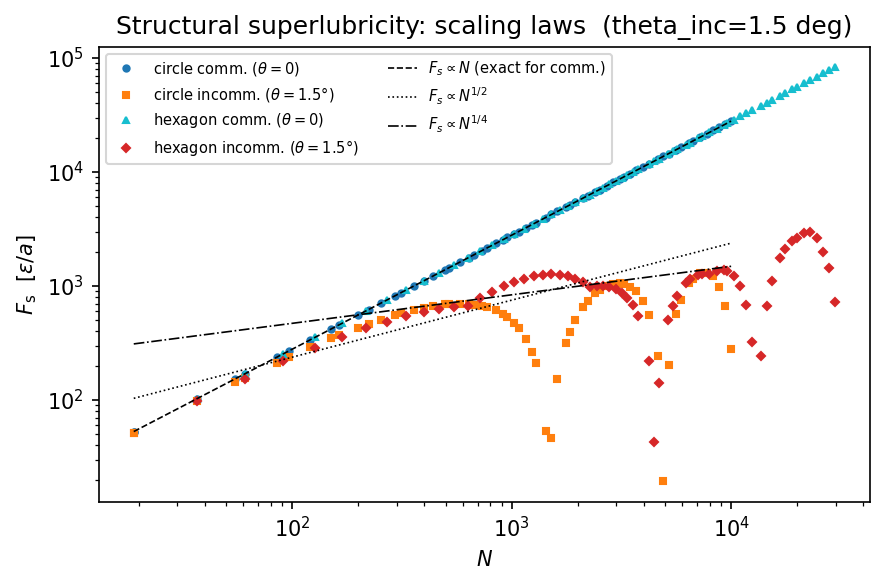

In [6]:
fig, ax = plt.subplots(dpi=150, figsize=(6, 4))

for shape in shapes:
    c_comm, c_inc = colors[shape]
    m_comm, m_inc = markers[shape]
    d = results[shape]
    ax.plot(d['Ns_comm'], d['Fs_comm'],
            marker=m_comm, ms=3, ls='none', color=c_comm,
            label=r'%s comm. ($\theta=0$)' % shape)
    ax.plot(d['Ns_inc'], d['Fs_inc'],
            marker=m_inc, ms=3, ls='none', color=c_inc,
            label=r'%s incomm. ($\theta=%.1f°$)' % (shape, theta_inc))

# Reference lines anchored to the data (not to F1s for the sqrt line,
# to allow for the finite-size offset at small N).
Nc = results['circle']['Ns_comm']
ax.plot(Nc, F1s * Nc,
        '--k', lw=0.8, label=r'$F_s \propto N$ (exact for comm.)')
ax.plot(Nc, 2. * (results['circle']['Fs_inc'][0] / Nc[0]**0.5) * Nc**0.5,
        ':k', lw=0.8, label=r'$F_s \propto N^{1/2}$')
ax.plot(Nc, 6. * (results['circle']['Fs_inc'][0] / Nc[0]**0.25) * Nc**0.25,
        '-.k', lw=0.8, label=r'$F_s \propto N^{1/4}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$N$')
ax.set_ylabel(r'$F_\mathrm{s}$  [$\epsilon/a$]')
ax.legend(fontsize=7, ncol=2)
ax.set_title('Structural superlubricity: scaling laws  (theta_inc=%.1f deg)' % theta_inc)
plt.tight_layout()
plt.show()

As expected:
  
  - **Commensurate**: $F_s$ grows **linearly** with $N$, matching $F_s = N \cdot F_{1s}$ exactly.
  - **Incommensurate**: $F_s$ grows **sublinearly**. At large $N$ the data approach
    $\sqrt{N}$; at small $N$ (cluster smaller than one Moiré tile) a steeper $N^{1/4}$
    behaviour is sometimes visible. Non-monotonic oscillations at intermediate $N$ are
    related to the number of complete Moiré tiles fitting in the cluster — each
    additional tile contributes a nearly-zero net force increment.
    
### References
[1] Dietzel et al., PRL 111, 235502 (2013) -- scaling laws of structural lubricity

[2] Koren & Duerig, PRB 94, 045401 (2016) -- moiré scaling in twisted graphene

[3] Panizon, Silva et al., Nanoscale 15, 1299 (2023) -- frictionless nanohighways

[4] Dienwiebel et al., PRL 92, 126101 (2004) -- superlubricity of graphite

[5] Cihan et al., Nat. Commun. 7, 12055 (2016) -- structural lubricity under ambient conditions

[6] Vanossi et al., Nat. Commun. 11, 4657 (2020) -- structural lubricity review